In [ ]:
import urllib.request
import zipfile
import os

try:
    os.mkdir("files")
except:
    pass

with urllib.request.urlopen('https://courses.cs.tau.ac.il/pyProg/2526a/resources/notebook_resources.zip') as f:
    content = f.read()

with open('files/notebook_resources.zip', 'wb') as f:
    f.write(content)

with zipfile.ZipFile('files/notebook_resources.zip', 'r') as zip_ref:
    zip_ref.extractall('files')

print(os.listdir('files'))

# Libraries: Numpy

## Python Programming for Engineers
### Tel-Aviv University / 0509-1820 / Fall 2025-2026

## Agenda: Numpy

- Intorduction
- Matrix operations
- Image processing
    - Basic operations
    - Binary segmentation
    - Ternary segmentation  
    ====== Next week =========
    - Morphological operators
    - Denoising
    - Image gradient
    - Image brightening


## Matrix Operations

## `import` numpy


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import imageio.v2 as imageio

#### NumPy Functions

#### Creation
| function                                                                                             | use                 | function                                                                                               | use                  |
| :--------------------------------------------------------------------------------------------------- | :------------------ | :----------------------------------------------------------------------------------------------------- | :------------------- |
| [np.array](https://numpy.org/doc/stable/reference/generated/numpy.array.html)                        | new array from list | [np.zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html)                          | array of zeros       |
| [np.ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html)                          | array of ones       | [np.arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)                        | evenly spaced values |
| [np.random.random](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random.html) | random floats 0-1   | [np.random.randint](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) | random ints in range |

#### Typing
| type                                                                            | use            | type                                                                          | use                  |
| :------------------------------------------------------------------------------ | :------------- | :---------------------------------------------------------------------------- | :------------------- |
| [np.uint8](https://numpy.org/devdocs/reference/arrays.scalars.html#numpy.uint8) | unsigned 0-255 | [np.int_](https://numpy.org/devdocs/reference/arrays.scalars.html#numpy.int_) | default integer type |





#### Array Manipulation
| function                                                                          | use                   | function                                                                    | use         |
| :-------------------------------------------------------------------------------- | :-------------------- | :-------------------------------------------------------------------------- | :---------- |
| [np.reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) | change array shape    | [np.sort](https://numpy.org/doc/stable/reference/generated/numpy.sort.html) | sorted copy |
| [np.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)       | limit values to range |                                                                             |             |
#### Numerical Ops
| function                                                                      | use         | function                                                                    | use        |
| :---------------------------------------------------------------------------- | :---------- | :-------------------------------------------------------------------------- | :--------- |
| [np.log](https://numpy.org/doc/stable/reference/generated/numpy.log.html)     | natural log | [np.log2](https://numpy.org/doc/stable/reference/generated/numpy.log2.html) | base-2 log |
| [np.log10](https://numpy.org/doc/stable/reference/generated/numpy.log10.html) | base-10 log |                                                                             |            |

#### Aggregation
| function                                                                             | use                             | function                                                                             | use              |
| :----------------------------------------------------------------------------------- | :------------------------------ | :----------------------------------------------------------------------------------- | :--------------- |
| [array.sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)         | sum                             | [array.mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html)       | mean             |
| [array.max](https://numpy.org/doc/stable/reference/generated/numpy.max.html)         | max                             | [array.min](https://numpy.org/doc/stable/reference/generated/numpy.min.html)         | min              |
| [array.argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)   | index of max                    | [array.argmin](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html)   | index of min     |
| [array.maximum](https://numpy.org/doc/stable/reference/generated/numpy.maximum.html) | element-wise max                | [array.minimum](https://numpy.org/doc/stable/reference/generated/numpy.minimum.html) | element-wise min |
| [array.any](https://numpy.org/doc/stable/reference/generated/numpy.any.html)         | any true                        | [array.all](https://numpy.org/doc/stable/reference/generated/numpy.all.html)         | all true         |
| [array.nonzero](https://numpy.org/doc/stable/reference/generated/numpy.nonzero.html) | coordinates of nonzero elements |       
| [array.shape](https://numpy.org/doc/stable/reference/generated/numpy.shape.html) | array dimensions | [array.T](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.T.html) | transpose ||                  |

#### Stacking/appending matrices vertically (add rows)

In [ ]:
a = np.array([[1,2,3],[4,5,6]])
b = np.array([[7,8,9],[1,1,1]])
print(np.vstack((a,b)))

#### Stacking/appending matrices horizontally (add columns)

In [ ]:
a = np.array([[1,2,3],[4,5,6]])
b = np.array([[7,8,9],[1,1,1]])
print(np.hstack((a,b)))

Slides 5-6

## Image processing with numpy

slides 7-9

## Grayscale image

### A table of integer values, aka pixels, each in the range of 0..255:
- 0 = Black
- 255 = White


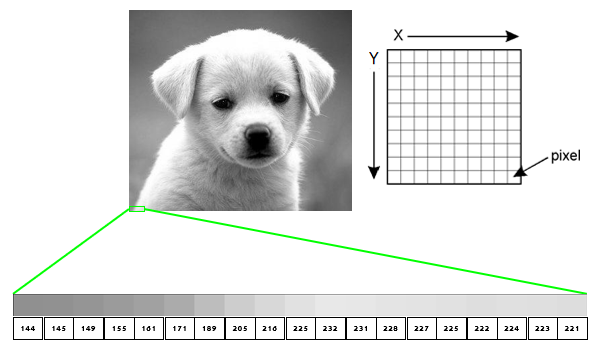


### Examples for image processing tasks

- **Binary segmentation**
    - Pixel>threshold -> white, else black
- **Ternary segmentation**
    - Mapping the whole brightness range to a fixed number of values
- **Image gradient**
    - Difference between neighboring pixels
- **Image brightening**
    - Making each pixel brighter
- **Morphological operators** 
    - Erosion – more black, less white
    - Dilation – more white, less black
- **Denoising**
    - recovering a clean image from a noisy one

### All these tasks can be achieved using matrix operation!

## Image processing - basic operations

#### Reading an image from disk:

In [ ]:
import imageio.v2 as imageio

In [ ]:
im = imageio.imread('files/evil_morty_1.png')
print(im)

print(type(im), im.shape)

#### Creating an “empty”(?) image matrix:

In [ ]:
height=20
width=20

im = np.zeros((height,width), dtype=np.uint8) 

#### <span style='color:red'> Important: each pixel is in the range 0-255 (type np.uint8) </span>

- Numerical operations cause overflow, e.g.: 
    - ```
    np.uint8(200) + np.uint8(100) = 44 = 300 mod 256
    ```


- Therefore, before doing numerical operations on image pixels, convert the whole image or a specific pixel to int 32-bit using np.int_
    - ```
    a = np.uint8(200)  
    b = np.uint8(100)
    np.int_(a) + np.int_(b) = 300
    ```
    

## Binary Segmentation

#### Goal: grayscale image $\rightarrow$ black and white image
- pixel > threshold $\rightarrow$ change to white (255)
- pixel <= threshold $\rightarrow$ change to black (0)


#### Motivation: for example, save space


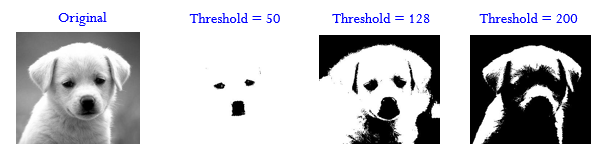

#### Implementation

In [ ]:
def segmentation(im, threshold):
    # find the pixels that are > threshold
    over_threshold = im > threshold

    # make them white (255)
    binary_image = over_threshold * 255
    
    return binary_image

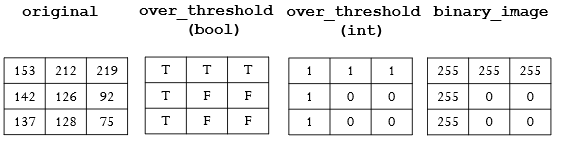

In [ ]:
im = imageio.imread('files/evil_morty_1.png')

In [ ]:
print(im)

In [ ]:
print(type(im))
print(im.shape, im.dtype)
print(np.min(im), np.max(im))

In [ ]:
plt.figure()  # opens a new figure window
plt.imshow(im, cmap=plt.cm.gray)

In [ ]:
threshold = 128 #Later we’ll learn how to optimize this threshold
bin_im = segmentation(im, threshold)

#### Show the binary image

In [ ]:
plt.figure()
plt.imshow(binary_image, cmap=plt.cm.gray)

## Ternary segmentation

#### Ternary segmentation – like binary segmentation but with 3 values.

- Transform grayscale to black/gray/white.

- First, find 2 thresholds (e.g, th1, th2) such that:
    - 1/3 pixels turn white     1/3 turn gray     1/3 turn black

- For example: If the values of the image pixels are 1 to 90 then:
    - first th1 = 30; th2 = 60

- Then for each pixel p assign:
    - 0 if  $p \le th1$ 
    - 128 if  $th1<p \le th2$  
    - 255 if  $th2 < p$

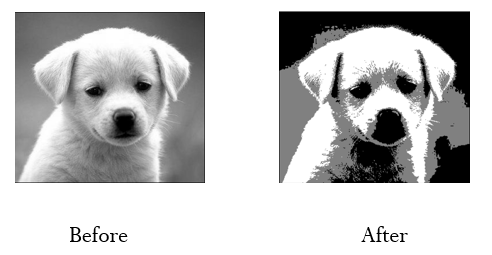


### Solution outline

#### We will break the problem into smaller problems:
1. Find 2 thresholds from cumulative histogram.  
    a. Create a histogram.  
    b. Create a cumulative histogram.  
    c. Find the thresholds  
2. Transform the image using the thresholds.  

## 2. Assume we have a `find_thrds(im)` function 
#### (we will implement it later, don’t worry).

#### Implement a `ternary_segmentation` function: 
- Input: a grayscale image
- Output: a new image where every pixel has one of 3 gray levels:
	0, 128 or 255

In [ ]:
def ternary_segmentation(im):
    th1, th2 = find_thrds(im)
    newIm = np.tile(0, im.shape)
    newIm[im > th1] = 128
    newIm[im > th2] = 255
    return newIm

Slides 34-39

## 1. Find thresholds

### 1.a. Image histogram

#### Implement the function build_hist(im):
- Input: grayscale image.
- Output: histogram of gray levels in image.

#### Our histogram is list with 256 values:
- Index = gray level
- Value = number of pixels with that gray level

|||
|--|--|
|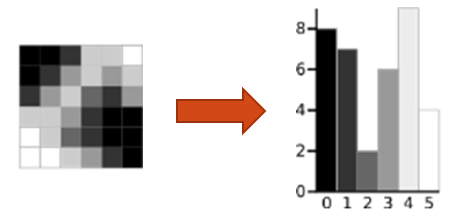|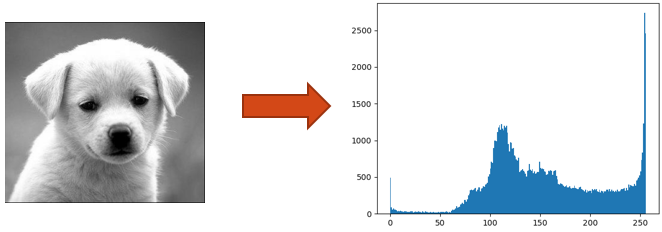|

In [ ]:
def build_hist(im):
    hist = [0]*256
    for r in range(im.shape[0]):
        for c in range(im.shape[1]):
            gray_level = im[r, c]
            hist[gray_level] += 1
    return hist

#Same as:
#return np.bincount(im.flatten())

### 1.b. Cumulative histogram

|||
|:--|:--|
|
<h4 id="implement-the-function-cumulative_sum">Implement the function cumulative sum(hist):</h4><ul><li>Input: histogram</li><li>Output: list of the cumulative sums of nums</li></ul>|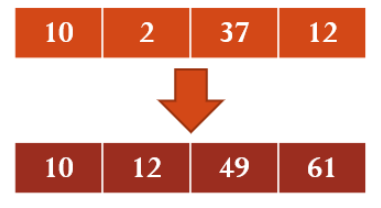
    </td></tr></table>|

In [2]:
def cumulative_sum(hist):
    if not hist: return []
    result = [hist[0]]
    for i in range(1,len(hist)):
        prev_sum = result[i-1]   
        result.append(prev_sum + hist[i])
    return result

#Same as:
#return [sum(hist[:i+1]) for i in range(len(hist))] 
#Or:    
#return list(np.cumsum(hist)) 

Slides 38-39

### 1.c. Finding the thresholds

#### Given an image, find two thresholds th1, th2 such that:

- $\frac{1}{3} $ of all pixels $\le$ th1 $\le \frac{2}{3}$ of all pixels    
- $\frac{2}{3} $ of all pixels $\le$ th2 $\le \frac{1}{3}$ of all pixels 
- In reality, the threshold is approximated by the **minimum value that is greater than the minimal fraction of pixels**


#### Solution: use `histogram` + `cumulative_sum`
- For example: for a 5X5 image with 7 gray levels (0-6):

In [3]:
hist = [1,5,4,8,3,3,1]
hist_cumulative_sum=cumulative_sum(hist) # [1,6,10,18,21,24,25]
sum_of_pixels=sum(hist)
print(f'histogram: {hist}')
print(f'cumulative histogram {hist_cumulative_sum}')
print(f'{hist_cumulative_sum[1]/sum_of_pixels} < 1/3 < {hist_cumulative_sum[2]/sum_of_pixels} --> th1=2') # th1=2
print(f'{hist_cumulative_sum[2]/sum_of_pixels} < 2/3 < {hist_cumulative_sum[3]/sum_of_pixels} --> th2=3') # th1=3

histogram: [1, 5, 4, 8, 3, 3, 1]
cumulative histogram [1, 6, 10, 18, 21, 24, 25]
0.24 < 1/3 < 0.4 --> th1=2
0.4 < 2/3 < 0.72 --> th2=3


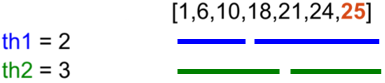

### Implementation of thresholds finding

In [ ]:
def find_thrds(im):
    hist = build_hist(im)
    cum_lst = cumulative_sum(hist)
    i = 0
    while cum_lst[i] / im.size < 1 / 3:
        i += 1
    th1 = i
    while cum_lst[i] / im.size < 2 / 3:
        i += 1
    th2 = i
    return th1, th2
#Or simply use:
#return np.percentile(im, 33), np.percentile(im, 66)

In [ ]:
im = imageio.imread('files/evil_morty_segmentation.png') 

In [ ]:
import matplotlib.pyplot as plt 
im1_transformed=ternary_segmentation(im)
fig,ax=plt.subplots()
ax.imshow(im1_transformed, cmap=plt.cm.gray)

# Self Learning

## Image gradient

- Given an image we may want to locate points of major change in intensity.
- We need to create a gradient image, so that every pixel is the **difference between the corresponding pixel in the original image and a neighboring pixel**.
- We can compute the gradient with reference to each of the image dimensions.

<table><tr>
<td>
    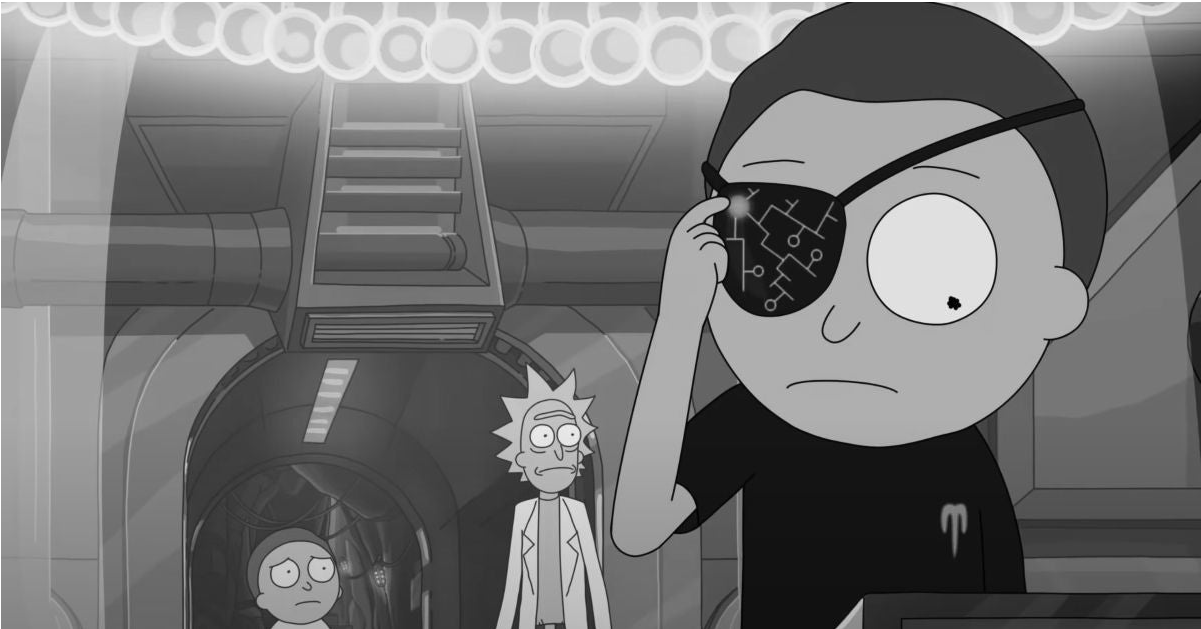
    </td>
<td>
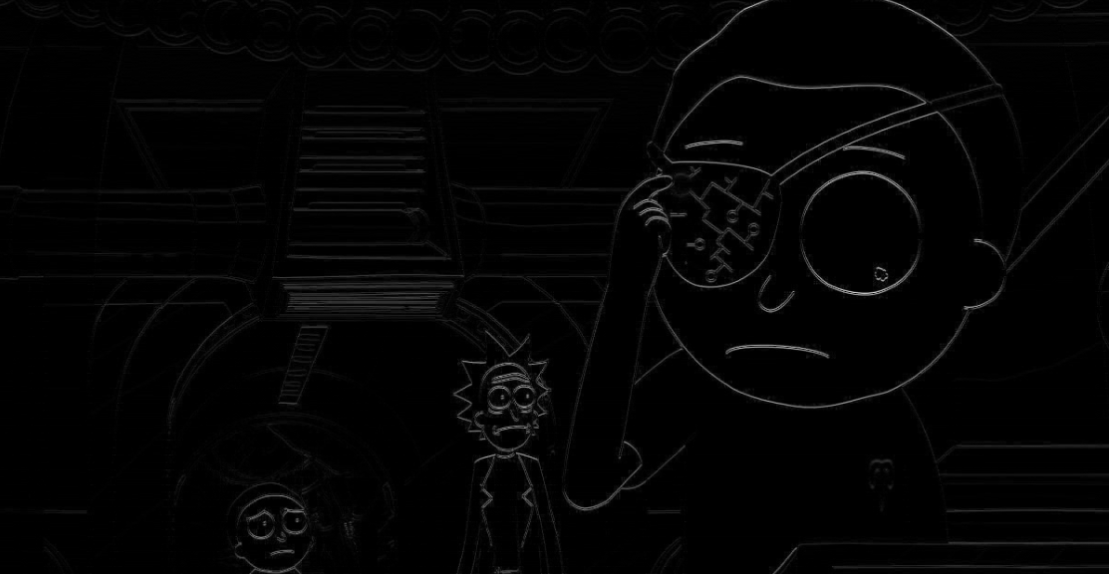
    </td></tr></table>

### How do we create such an image?

#### Shift up and subtract images
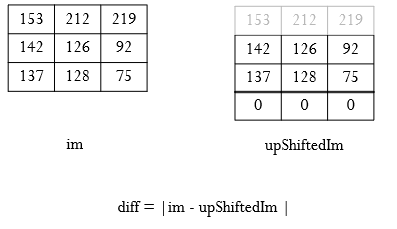


Implement the function `create_gradient(im)` that gets an image and returns the vertical gradient image as detailed above.

**hint**: Create the matrix `upshifted_im` (im without the first row and add a row of zeros). Then create the matrix `diff`.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

In [7]:
im = imageio.imread('files/evil_morty_segmentation.png')

In [ ]:
def create_gradient(im):
    # Write your code here
    pass

gradient = create_gradient(im)
plt.figure(figsize=(15,15))
plt.imshow(gradient, cmap=plt.cm.gray)

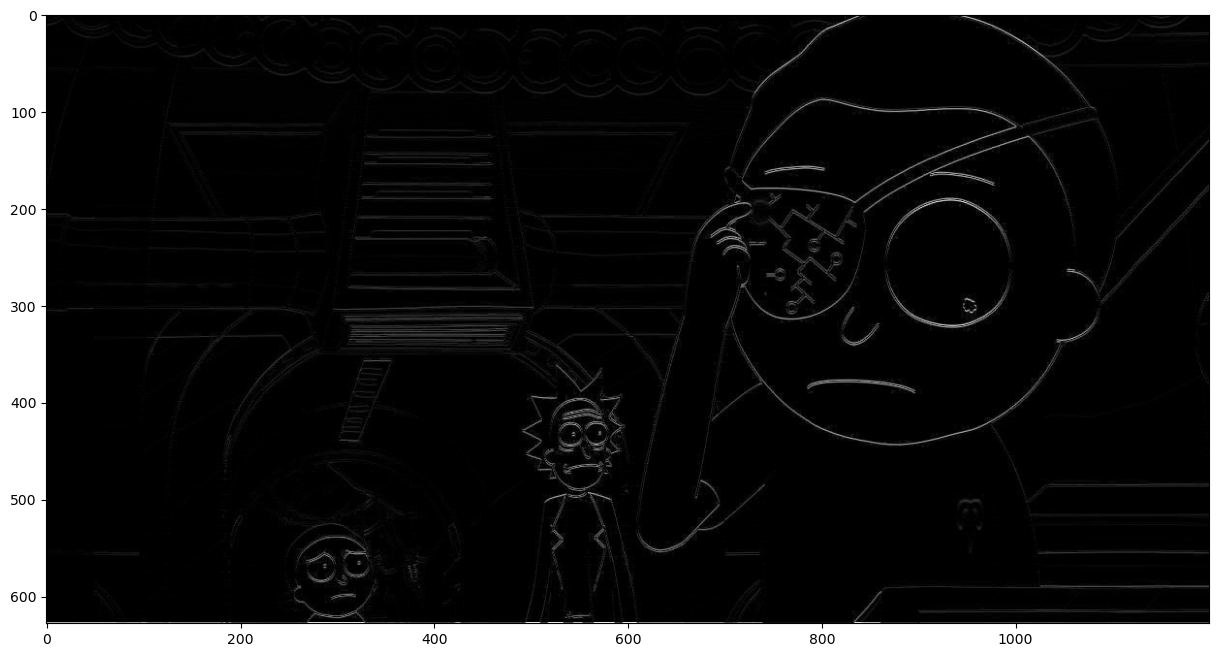

In [8]:
# Solution
def create_gradient(im):
    # Create upshifted_im
    zero_row = np.zeros((1,im.shape[1]), dtype=np.int_)
    upshifted_im = np.vstack((im[1:,:], zero_row))
    
    # Create diff
    diff = np.int_(upshifted_im) - np.int_(im)
    abs_diff = np.abs(diff)
    return abs_diff

gradient = create_gradient(im)
plt.figure(figsize=(15,15))
plt.imshow(gradient, cmap=plt.cm.gray)

#### Can it also be computed using `for` loops?

## Brighening an image

#### Problem: We can hardly see the gradient image.
- let’s brighten it.

Implement the function `brighten_gradient(gr)` that brightens each pixel 5-fold (times 5).
This will significantly brighten every pixel that is not completely black.

In [ ]:
def brighten_gradient(gr):
    # Write your code here
    pass

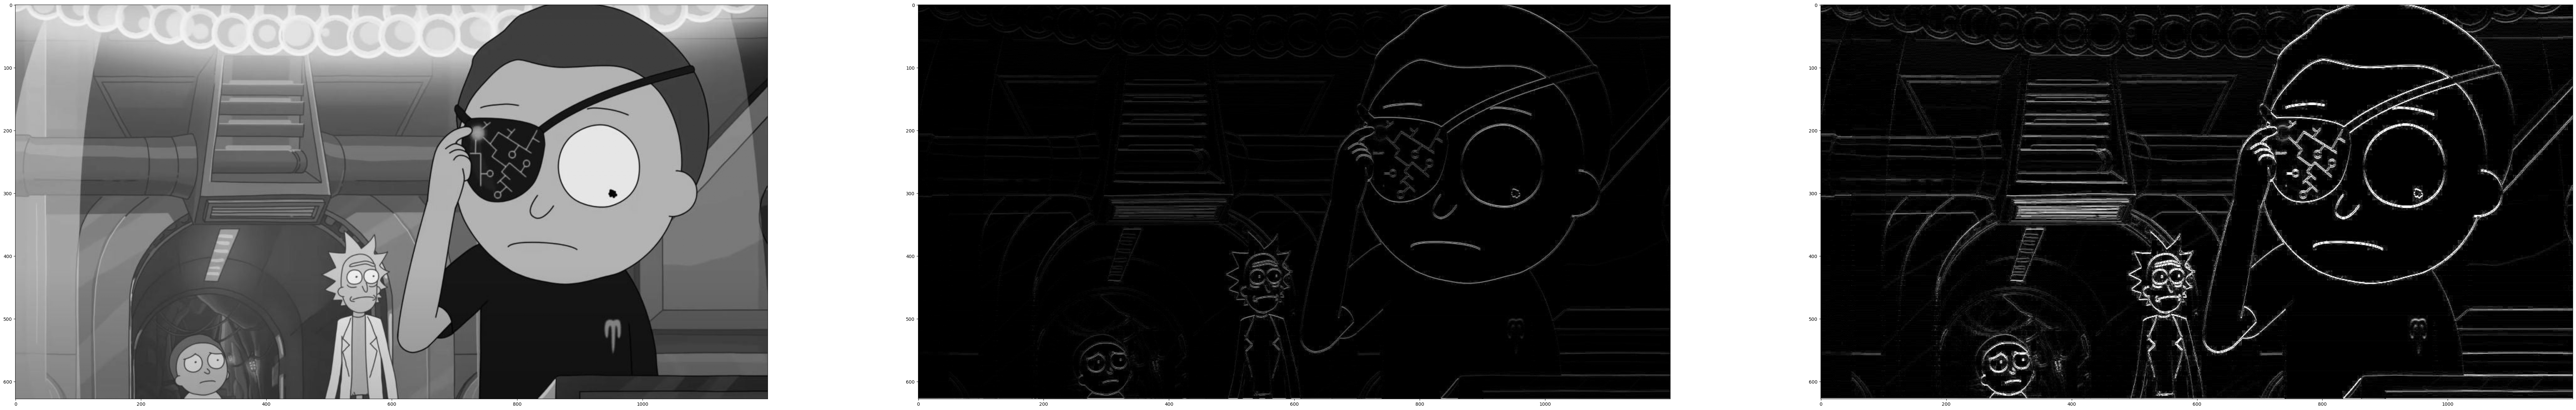

In [9]:
# Solution
def brighten_gradient(gr):
    brighten_gr = gr * 5
    more_than_255 = gr > 255
    gr[more_than_255] = 255
    return gr

# Better solution
def brighten_gradient(gr):
    return np.minimum(gr * 5, 255)

brighten_gr = brighten_gradient(gradient)

fig,ax=plt.subplots(1,3, figsize=(100,40))
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(gradient, cmap=plt.cm.gray)
ax[2].imshow(brighten_gr, cmap=plt.cm.gray)

Slide 46

## Question from previous exams

[Exam 2023-2024 semester A Moed B](https://courses.cs.tau.ac.il/pyProg/2425a/exams/exam2324a_moedB.pdf)

3.A

In [ ]:
def convert_to_binary(im):
    res = np.zeros(im.shape)
    flt = im.flatten()
    bc = np.bincount(flt)
    am = np.argmax(bc)
    res[im >= am] = 255
    return res


In [ ]:
arr=np.array([[1,2,5],[4,4,3]])
convert_to_binary(arr)

3.B

In [ ]:
def encode_row_helper(im_row):
    im_row_shift=np.hstack((np.array([255]), im_row))
    idxs=np.nonzero(np.diff(im_row_shift))[0]
    return idxs

def encode_row(im_row):
    idxs = encode_row_helper(im_row)
    idx_diff = np.diff(np.hstack((idxs, [len(im_row)])))
    return np.hstack(([idxs[0]],idx_diff))

im_row =[255,0,255,255]
print(encode_row(im_row))

3.C

In [ ]:
def encode(im):
    ar = np.array([])
    for a in range(im.shape[0]):
        ar = np.hstack((ar, encode_row(im[a]), [-1]))
    return ar[:-1]

im_bin=np.array([[0,0,255,255],
[255,0,255,255],
[0,0,255,255]])
encode(im_bin)

3.D

In [ ]:
def calc_ratio(im,im_enc):
    return np.sum(im_enc[im_enc != -1]) / im.size

im=np.array([[0, 1, 2, 3],
             [2, 1, 2, 3],
             [0, 1, 2, 3]])

im_bin = convert_to_binary(im)
im_enc = encode(im_bin)
print(calc_ratio(im_bin,im_enc))

## Numpy: summary

#### Many more operations can be performed on images, in particular:
- Numpy is very convenient library for numerical manipulations
- Can be used for geometric transformations: rotation, flipping, resizing, etc.
- Many application, including image processsing, which we covered thouroughly.